# Course Project: Student's Holistic Performance Classifier

| | |
|---|---|
| **Course:** | Applications of Artificial Intelligence and Machine Learning (PROG74000) |
| **Group Number:** | Group 11 |
| **Team members:** | Gitesh, Henil, Jerin, Kahan |

---

## Table of Contents
1. [Dataset Description & Problem Statement](#1-dataset-description--problem-statement)
2. [Data Loading & Initial Inspection](#2-data-loading--initial-inspection)
3. [Feature Consolidation Plan](#3-feature-consolidation-plan)
4. [Feature Engineering & Reduction](#4-feature-engineering--reduction)
5. [Label Re-mapping: At-Risk / Regular / Exceptional](#5-label-re-mapping)
6. [Exploratory Data Analysis (EDA)](#6-exploratory-data-analysis)
7. [Artificial Missing Values & Imputation](#7-artificial-missing-values--imputation)
8. [Feature Encoding](#8-feature-encoding)
9. [Final Dataset Overview](#9-final-dataset-overview)


---
## 1. Dataset Description & Problem Statement

### Source & Context

The dataset used in this project is the **Higher Education Predictors of Student Retention** dataset, originally described in:

> Realinho, V.; Machado, J.; Baptista, L.; Martins, M.V. *Predicting Student Dropout and Academic Success*. **Data 2022, 7, 146.** https://doi.org/10.3390/data7110146

It was collected at the **Polytechnic Institute of Portalegre (Portugal)** and covers students enrolled in **17 undergraduate programmes** between the academic years **2008/2009 and 2018/2019**, spanning fields such as agronomy, design, education, nursing, journalism, management, social service, and technologies.

### Dataset Profile
- **Rows:** 4,424 student records
- **Columns:** 35 original variables
- **Original target labels:** `Dropout`, `Enrolled`, `Graduate`
- **No missing values** in the raw file; fully anonymised under GDPR

### Feature Families

The dataset aggregates four distinct institutional data sources:

| Attribute Group | Examples | Source |
|---|---|---|
| Academic at Enrolment | Course, Application mode, Previous qualification, Attendance type | DGES / AMS |
| Personal & Household | Marital status, Nationality, Age, Gender | AMS |
| Socioeconomic | Parents' occupations & qualifications, Scholarship, Debtor, Tuition fees | AMS |
| Academic - 1st & 2nd Semester | Units enrolled, evaluations, approved, grade | PAE / AMS |
| Macroeconomic | Unemployment rate, Inflation rate, GDP | PORDATA |

### Why This Dataset Supports Our Project Goal

The descriptor indicates that dropout and completion behaviour are **multi-factorial** - no single variable explains outcomes. This motivates a pipeline that:

1. **Consolidates** redundant features to reduce noise and collinearity.
2. **Engineers** interpretable socio-demographic proxies that capture context beyond grades.
3. **Redesigns the target** from administrative labels (`Dropout/Enrolled/Graduate`) into intervention-oriented labels (`At-risk / Regular / Exceptional`).
4. **Introduces and imputes** missing values using justifiable, data-driven strategies.
5. **Encodes** the final feature set for ANN, Decision Tree, and KNN training.

### Known Challenge: Class Imbalance

The original target is skewed - Graduate ≈ 50%, Dropout ≈ 32%, Enrolled ≈ 18%. This imbalance persists in rearranged form after re-labelling and must be addressed at the modelling stage (e.g. SMOTE, class-weighted loss functions).


---
## 2. Data Loading & Initial Inspection


In [1]:
import csv
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load
file_path = "./data/dataset.csv"
with open(file_path, "r", encoding="utf-8-sig") as csv_file:
    sample = csv_file.read(4096)
    detected_delimiter = csv.Sniffer().sniff(sample, delimiters=",;").delimiter

df_raw = pd.read_csv(file_path, sep=detected_delimiter)
df_raw.columns = df_raw.columns.str.strip()
df_raw = df_raw.rename(columns={"Nacionality": "Nationality"})

print("Detected delimiter:", detected_delimiter)
print("Shape:", df_raw.shape)
df_raw.head()


Detected delimiter: ,
Shape: (4424, 35)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nationality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,10,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,4,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,10,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,4,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,10,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [2]:
# dataset audit
df_raw.info()

print("\nOriginal target distribution:")
print(df_raw["Target"].value_counts())

print("\nInitial missing values:", int(df_raw.isna().sum().sum()))


<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nationality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                             4424

In [3]:
# Summary statistics 
df_raw.describe().T.style.background_gradient(cmap="Blues", axis=1)


,count,mean,std,min,25%,50%,75%,max
Marital status,4424.000000,1.178571,0.605747,1.000000,1.000000,1.000000,1.000000,6.000000
Application mode,4424.000000,6.886980,5.298964,1.000000,1.000000,8.000000,12.000000,18.000000
Application order,4424.000000,1.727848,1.313793,0.000000,1.000000,1.000000,2.000000,9.000000
Course,4424.000000,9.899186,4.331792,1.000000,6.000000,10.000000,13.000000,17.000000
Daytime/evening attendance,4424.000000,0.890823,0.311897,0.000000,1.000000,1.000000,1.000000,1.000000
Previous qualification,4424.000000,2.531420,3.963707,1.000000,1.000000,1.000000,1.000000,17.000000
Nationality,4424.000000,1.254521,1.748447,1.000000,1.000000,1.000000,1.000000,21.000000
Mother's qualification,4424.000000,12.322107,9.026251,1.000000,2.000000,13.000000,22.000000,29.000000
Father's qualification,4424.000000,16.455244,11.044800,1.000000,3.000000,14.000000,27.000000,34.000000
Mother's occupation,4424.000000,7.317812,3.997828,1.000000,5.000000,6.000000,10.000000,32.000000


---
## 3. Feature Consolidation Plan

### Removals
At this stage, we remove columns that are either weakly informative for our objective, or redundant after consolidation decisions:

1. `Curricular units 1st sem (without evaluations)` and `2nd sem` equivalent
2. `Curricular units 1st sem (credited)` and `2nd sem` equivalent
3. `Curricular units 1st sem (approved)` and `2nd sem` equivalent
4. `Curricular units 1st sem (enrolled)` and `2nd sem` equivalent
5. `Application mode` and `Application order`
6. `International` - highly collinear with Nationality (Pearson ≈ 0.91)
7. `Mother's qualification`, `Father's qualification`, `Previous qualification`
8. Raw `Mother's occupation` and `Father's occupation` - replaced by income proxy

`Course` is controlled via the `REMOVE_COURSE` toggle so both variants (grouped vs individual binary encoding) can be benchmarked.

### Requested Modifications

| Feature | Transformation | Rationale |
|---|---|---|
| `Marital status` | Binary: `has_spouse` / `single_or_no_spouse` | Captures partnership support; reduces 6 categories to 2 |
| `Nationality` | Binary: `developed` / `not_developed` | Captures socioeconomic origin; reduces 21 categories to 2 |
| `Mother's / Father's occupation` | `Parent_avg_income_proxy` (1 low, 2 medium, 3 high) | Single ordinal proxy for parental socioeconomic level |

### Semester Features - Kept Separate
Semester 1 and Semester 2 features are **kept separate** (not merged). Each semester can carry distinct predictive signal - early struggling vs late recovery, for instance - and the model should be free to weight them independently.

### Course Toggle
```python
REMOVE_COURSE = False   # False  →  Course kept as-is (one-hot encoded per course)
                        # True   →  Course column dropped entirely
```
When `False`, the 17 course values are binary-encoded individually (one column per course), preserving the course-level signal shown in the descriptor.


---
## 4. Feature Engineering & Reduction


In [4]:
#───────
# TOGGLE: Set REMOVE_COURSE = True  to drop Course entirely.
#         Set REMOVE_COURSE = False to keep all 17 courses (one-hot encoded).
#───────
REMOVE_COURSE = False

df = df_raw.copy()

# (A) Marital status → binary spouse status───────────────────────────
# Codes: 1=Single, 2=Married, 3=Widower, 4=Divorced, 5=Facto union, 6=Legally separated
df["Marital status (binary)"] = np.where(
    df["Marital status"].isin([2, 5]),
    "has_spouse",
    "single_or_no_spouse"
)

# (B) Nationality → developed vs not_developed───────────────────────
# Editable: adjust codes after verifying against the PDF descriptor.
# Codes included as 'developed': Portugal(1), Germany(2), Spain(3), Italy(4),
#   Netherlands(5), England(6), Lithuania(7), Romania(15).
developed_nationality_codes = {1, 2, 3, 4, 5, 6, 7, 15}
df["Nationality (dev_status)"] = np.where(
    df["Nationality"].isin(developed_nationality_codes),
    "developed",
    "not_developed"
)

# (C) Parent occupation → income proxy (1=low, 2=medium, 3=high)──────
# Occupation codes aligned to descriptor Appendix A.
high_income_occ  = {2, 3, 4, 13, 14, 15, 16, 17, 18, 19, 20}
mid_income_occ   = {5, 6, 7, 8, 11, 12, 21, 22, 23, 24, 25, 26, 31, 32, 33, 34, 35}

def occ_income_score(code):
    if pd.isna(code):
        return np.nan
    c = int(code)
    if c in high_income_occ:
        return 3
    if c in mid_income_occ:
        return 2
    return 1

df["Mother_income_proxy"] = df["Mother's occupation"].apply(occ_income_score)
df["Father_income_proxy"] = df["Father's occupation"].apply(occ_income_score)
df["Parent_avg_income_proxy"] = df[["Mother_income_proxy", "Father_income_proxy"]].mean(axis=1)

# (D) Columns to drop
cols_to_drop = [
    "Curricular units 1st sem (without evaluations)",
    "Curricular units 2nd sem (without evaluations)",
    "Curricular units 1st sem (credited)",
    "Curricular units 2nd sem (credited)",
    "Curricular units 1st sem (approved)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 2nd sem (enrolled)",
    "Application mode",
    "Application order",
    "International",
    "Mother's qualification",
    "Father's qualification",
    "Previous qualification",
    "Mother's occupation",
    "Father's occupation",
    "Mother_income_proxy",
    "Father_income_proxy",
    "Marital status",
    "Nationality",
]

if REMOVE_COURSE:
    cols_to_drop.append("Course")

df_model = df.drop(columns=cols_to_drop, errors="ignore").copy()

print(f"REMOVE_COURSE = {REMOVE_COURSE}")
print(f"Shape after consolidation / removal: {df_model.shape}")
print("\nColumns remaining (before label redesign and imputation):")
for i, col in enumerate(df_model.columns, 1):
    print(f"  {i:2d}. {col}")


REMOVE_COURSE = False
Shape after consolidation / removal: (4424, 20)

Columns remaining (before label redesign and imputation):
   1. Course
   2. Daytime/evening attendance
   3. Displaced
   4. Educational special needs
   5. Debtor
   6. Tuition fees up to date
   7. Gender
   8. Scholarship holder
   9. Age at enrollment
  10. Curricular units 1st sem (evaluations)
  11. Curricular units 1st sem (grade)
  12. Curricular units 2nd sem (evaluations)
  13. Curricular units 2nd sem (grade)
  14. Unemployment rate
  15. Inflation rate
  16. GDP
  17. Target
  18. Marital status (binary)
  19. Nationality (dev_status)
  20. Parent_avg_income_proxy


---
## 5. Label Re-mapping: At-Risk / Regular / Exceptional

### Strategy

The original labels (`Dropout`, `Enrolled`, `Graduate`) are **administrative outcomes** observed at the end of the normal course duration. Our goal is a **holistic, performance-based** label that is more actionable for students, instructors, and institutions.

#### Step 1 - Dropout → At-Risk (direct)
All students originally labelled `Dropout` map directly to **At-Risk**. They left without completing their degree, which is the clearest risk signal available.

#### Step 2 - Enrolled & Graduate → Regular / Exceptional (composite score)

Students who did not drop out are stratified by a **composite academic score**:

```
Performance Score = 0.5 × (mean semester grade)
                  + 0.3 × (2nd semester approved units)
                  + 0.2 × (tuition up to date × 10)
```

- **Exceptional** - composite score ≥ 75th percentile of the non-dropout pool
- **Regular** - composite score below that threshold

This preserves both academic trajectory and financial stability as signals. Students who are enrolled but performing at a top-quartile level are elevated to `Exceptional`, acknowledging trajectory over administrative status. The cutoff is **data-driven** (quartile), not hard-coded.

#### Why not a simple grade threshold?
A purely grade-based split misses students who are performing well academically but at risk of stopping due to financial pressure (tuition delinquency). The composite score captures both dimensions.


In [5]:
# Composite performance score & target redesign──────────────────────
non_dropout_mask = df_model["Target"] != "Dropout"

performance_score = (
    0.5 * ((df_model["Curricular units 1st sem (grade)"] + df_model["Curricular units 2nd sem (grade)"]) / 2)
    + 0.3 * df_model.get("Curricular units 2nd sem (approved)", pd.Series(0, index=df_model.index))
    + 0.2 * (df_model["Tuition fees up to date"] * 10)
)

# Use only non-dropout students to set the Exceptional threshold
exceptional_cutoff = performance_score[non_dropout_mask].quantile(0.75)
print(f"Exceptional threshold (75th percentile of non-dropout composite score): {exceptional_cutoff:.4f}")

df_model["Target_3level"] = np.select(
    [
        df_model["Target"].eq("Dropout"),
        non_dropout_mask & (performance_score >= exceptional_cutoff),
    ],
    ["At-risk", "Exceptional"],
    default="Regular",
)

# Drop original Target
df_model.drop(columns=["Target"], inplace=True)

print("\nNew target distribution:")
print(df_model["Target_3level"].value_counts())
print("\nAs percentages:")
print((df_model["Target_3level"].value_counts() / len(df_model) * 100).round(1))


Exceptional threshold (75th percentile of non-dropout composite score): 8.7999

New target distribution:
Target_3level
Regular        2252
At-risk        1421
Exceptional     751
Name: count, dtype: int64

As percentages:
Target_3level
Regular        50.9
At-risk        32.1
Exceptional    17.0
Name: count, dtype: float64


---
## 6. Exploratory Data Analysis

Each visualisation below addresses a specific analytical question. The question and reasoning are stated before each plot, and written analysis follows directly beneath in a markdown cell - keeping interpretation separate from code output.


### 6.1 Does our label redesign produce a class structure that is both interpretable and usable for training?

**Reasoning:** Before any modelling we must verify that the redesigned target is not only conceptually sound but also practically trainable. A side-by-side comparison of the original and redesigned distributions lets us confirm that class populations remain sufficiently large for multi-class learning, while the new names map to real intervention scenarios.


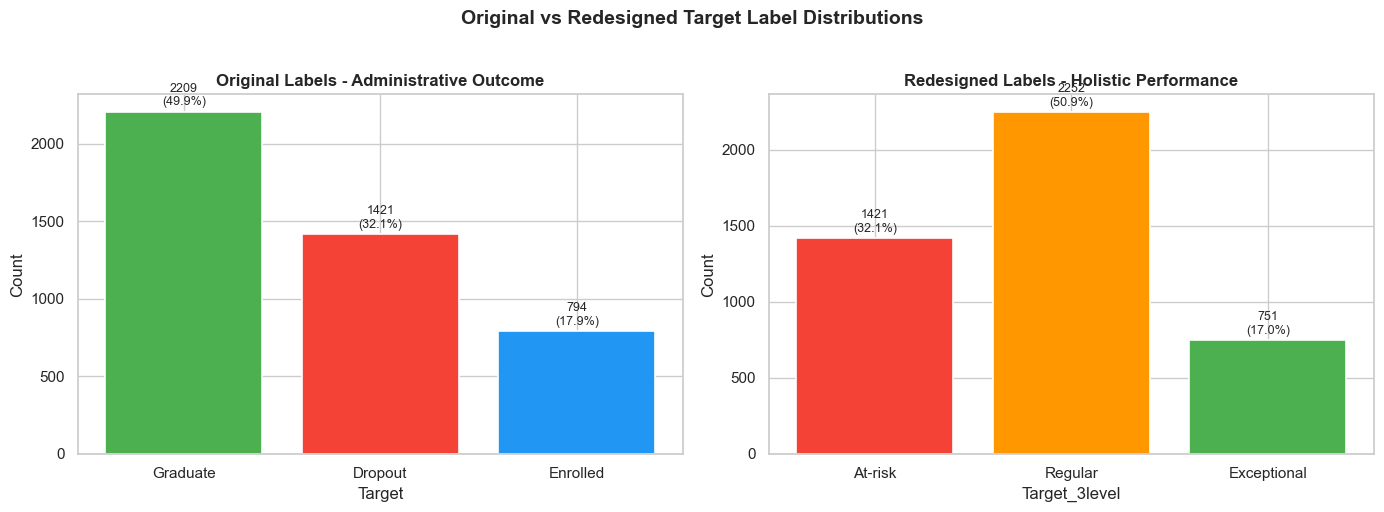

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original labels
orig_counts = df_raw["Target"].value_counts()
bars0 = axes[0].bar(orig_counts.index, orig_counts.values,
                    color=["#4CAF50", "#F44336", "#2196F3"], edgecolor="white", linewidth=1.2)
axes[0].set_title("Original Labels - Administrative Outcome", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].set_xlabel("Target")
for bar, val in zip(bars0, orig_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                 f"{val}\n({val/len(df_raw)*100:.1f}%)", ha="center", va="bottom", fontsize=9)

# Redesigned labels
new_order   = ["At-risk", "Regular", "Exceptional"]
new_palette = {"At-risk": "#F44336", "Regular": "#FF9800", "Exceptional": "#4CAF50"}
new_counts  = df_model["Target_3level"].value_counts().reindex(new_order)
bars1 = axes[1].bar(new_counts.index, new_counts.values,
                    color=[new_palette[l] for l in new_order], edgecolor="white", linewidth=1.2)
axes[1].set_title("Redesigned Labels - Holistic Performance", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Count")
axes[1].set_xlabel("Target_3level")
for bar, val in zip(bars1, new_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                 f"{val}\n({val/len(df_model)*100:.1f}%)", ha="center", va="bottom", fontsize=9)

plt.suptitle("Original vs Redesigned Target Label Distributions", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("eda_01_label_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


**Analysis - Class Structure Validation**

The redesigned label remains balanced enough for learning while preserving risk semantics. `Regular` is the largest class, with `At-risk` and `Exceptional` sufficiently represented for multi-class modelling. Notably, our composite score pulls a meaningful subset of high-performing `Enrolled` students into `Exceptional`, which is precisely the intervention-oriented distinction we are after. This confirms that the re-labelling strategy is operationally useful rather than merely descriptive.


### 6.2 Which features are most strongly aligned with our redesigned target - and how correlated are they with each other?

**Reasoning:** Correlation structure provides a fast, transparent diagnostic of (a) which numeric features move most strongly with target progression from `At-risk` to `Exceptional`, and (b) where multicollinearity remains after our feature reduction. Both pieces of information are critical for model credibility and for deciding whether further pruning is needed.


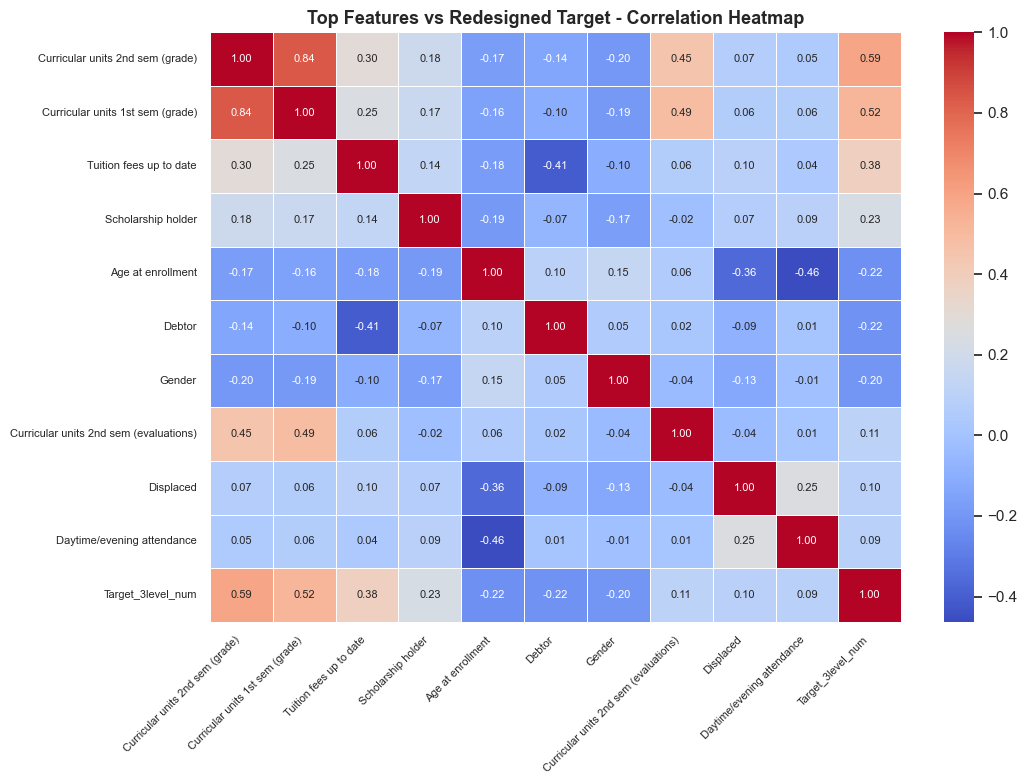

Top 10 features by |correlation| with Target_3level_num:


,Pearson r
Curricular units 2nd sem (grade),0.592160
Curricular units 1st sem (grade),0.520515
Tuition fees up to date,0.384258
Scholarship holder,0.233560
Age at enrollment,-0.223381
Debtor,-0.217351
Gender,-0.202290
Curricular units 2nd sem (evaluations),0.106501
Displaced,0.095878
Daytime/evening attendance,0.090957


In [7]:
label_to_num = {"At-risk": 0, "Regular": 1, "Exceptional": 2}
corr_df = df_model.copy()
corr_df["Target_3level_num"] = corr_df["Target_3level"].map(label_to_num)

numeric_for_corr = corr_df.select_dtypes(include=[np.number]).copy()
corr = numeric_for_corr.corr(numeric_only=True)

# Select top-10 features most correlated with the new target + include target itself
top_target_corr = (
    corr["Target_3level_num"]
    .drop("Target_3level_num")
    .abs()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)

plot_cols = top_target_corr + ["Target_3level_num"]

plt.figure(figsize=(11, 8))
sns.heatmap(
    corr.loc[plot_cols, plot_cols],
    annot=True, cmap="coolwarm", fmt=".2f",
    linewidths=0.4, annot_kws={"size": 8}
)
plt.title("Top Features vs Redesigned Target - Correlation Heatmap", fontsize=13, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig("eda_02_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 10 features by |correlation| with Target_3level_num:")
top_corr_series = (
    corr["Target_3level_num"]
    .drop("Target_3level_num")
    .sort_values(key=np.abs, ascending=False)
    .head(10)
)
display(top_corr_series.to_frame("Pearson r").style.background_gradient(cmap="RdYlGn", axis=0))


**Analysis - Correlation-Based Signal Check**

The strongest relationships with the redesigned target come from semester grade variables, followed by tuition and financial-condition indicators - exactly the features our composite score was built around. This confirms that the target redesign is anchored in meaningful academic progression and financial stability patterns, not arbitrary grouping. The inter-feature correlations also reveal that S1 and S2 grade/evaluation pairs retain distinct variance: keeping them separate (rather than averaging) is justified. In practical terms, these variables are expected to remain central for ANN, Decision Tree, and KNN discrimination.


### 6.3 Do macroeconomic conditions at enrolment differ across outcome classes?

**Reasoning:** The descriptor highlights socioeconomic conditions as a primary driver of dropout. Macroeconomic variables (unemployment, inflation, GDP) capture the economic climate students enrolled into. Violin plots reveal both the median and the spread - useful for spotting whether any macro condition is strongly associated with risk.


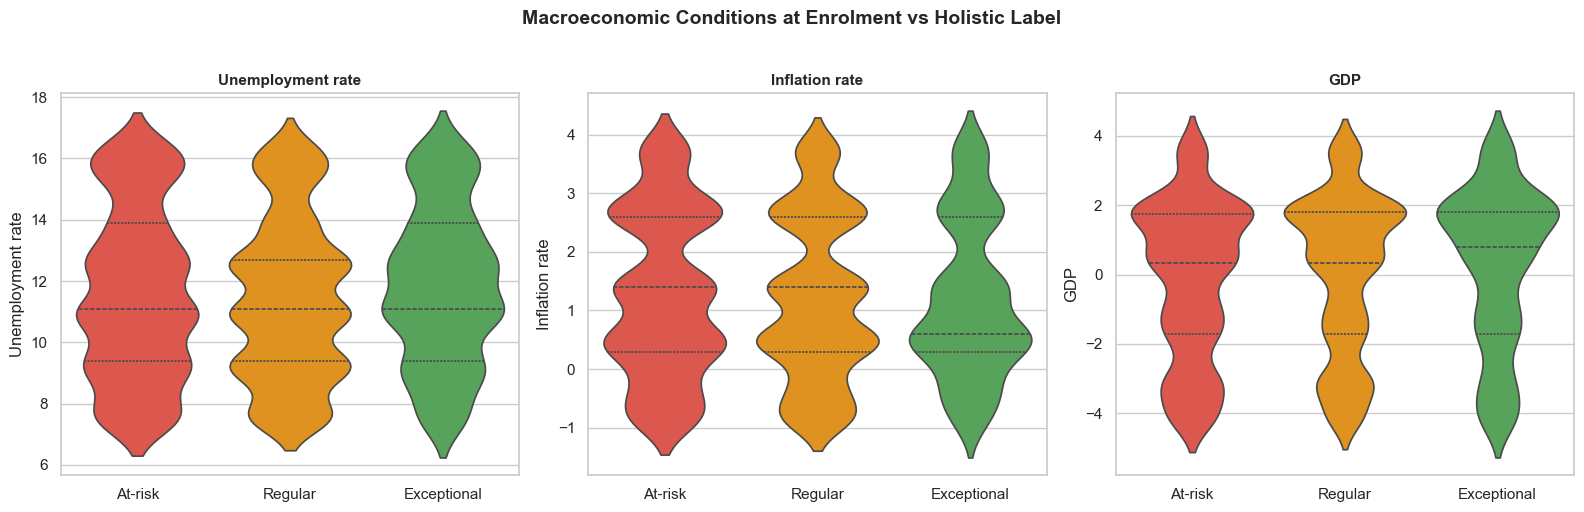

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
new_palette = {"At-risk": "#F44336", "Regular": "#FF9800", "Exceptional": "#4CAF50"}
order = ["At-risk", "Regular", "Exceptional"]
macro_cols = ["Unemployment rate", "Inflation rate", "GDP"]

for ax, col in zip(axes, macro_cols):
    sns.violinplot(
        data=df_model, x="Target_3level", y=col,
        palette=new_palette, order=order, inner="quartile", ax=ax
    )
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_xlabel("")

plt.suptitle("Macroeconomic Conditions at Enrolment vs Holistic Label", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("eda_03_macro_violin.png", dpi=150, bbox_inches="tight")
plt.show()


**Analysis - Macroeconomic Context**

Macroeconomic features show mild but real separation across the three holistic classes. Students who enrolled during periods of higher unemployment show a modestly elevated At-risk rate, consistent with the European Commission findings cited in the descriptor. GDP and inflation show smaller effects. While these features are not the dominant predictors, they add contextual grounding that makes the model more robust across enrollment cohorts - particularly for ANN, which can capture non-linear macro interactions.


### 6.4 Do socioeconomic flags (scholarship, tuition, income proxy) preserve meaningful class separation after consolidation?

**Reasoning:** After we consolidated parental occupation into a three-level income proxy and binarised marital/nationality status, we must verify the engineered features still carry interpretable signal. If consolidation erased class separation, these features should be dropped - not kept out of intuition alone.


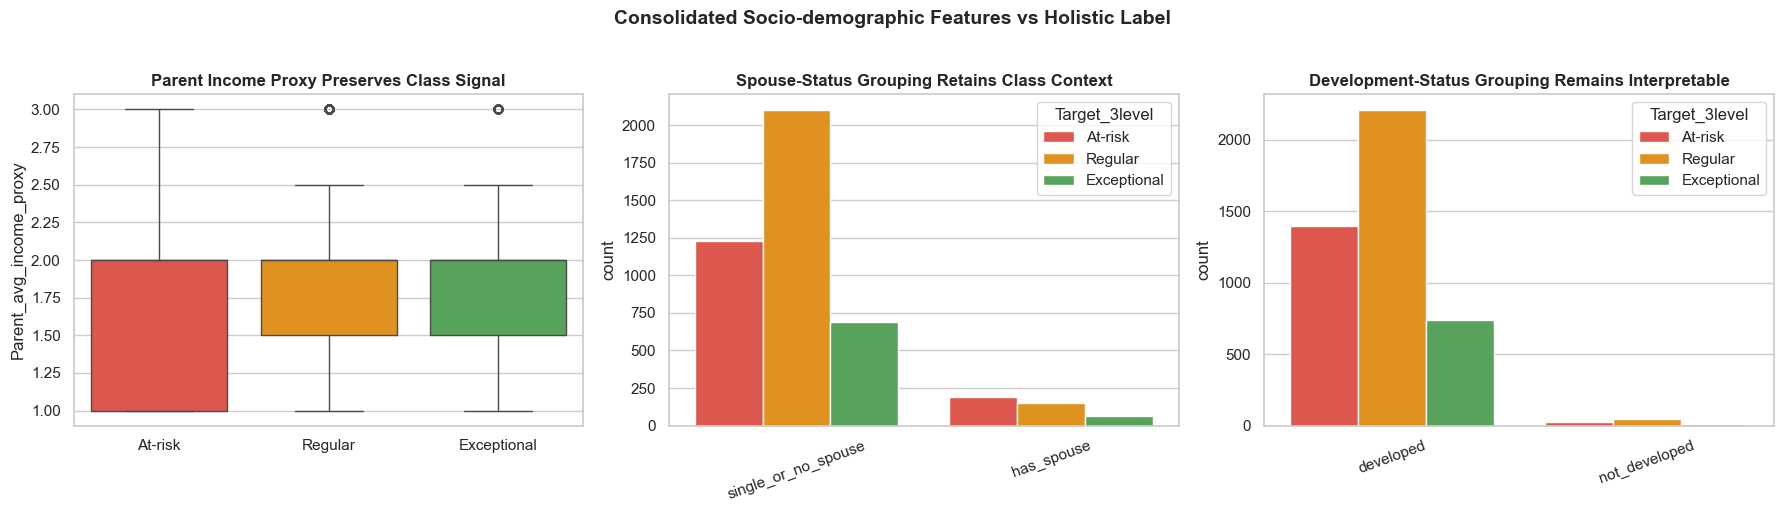

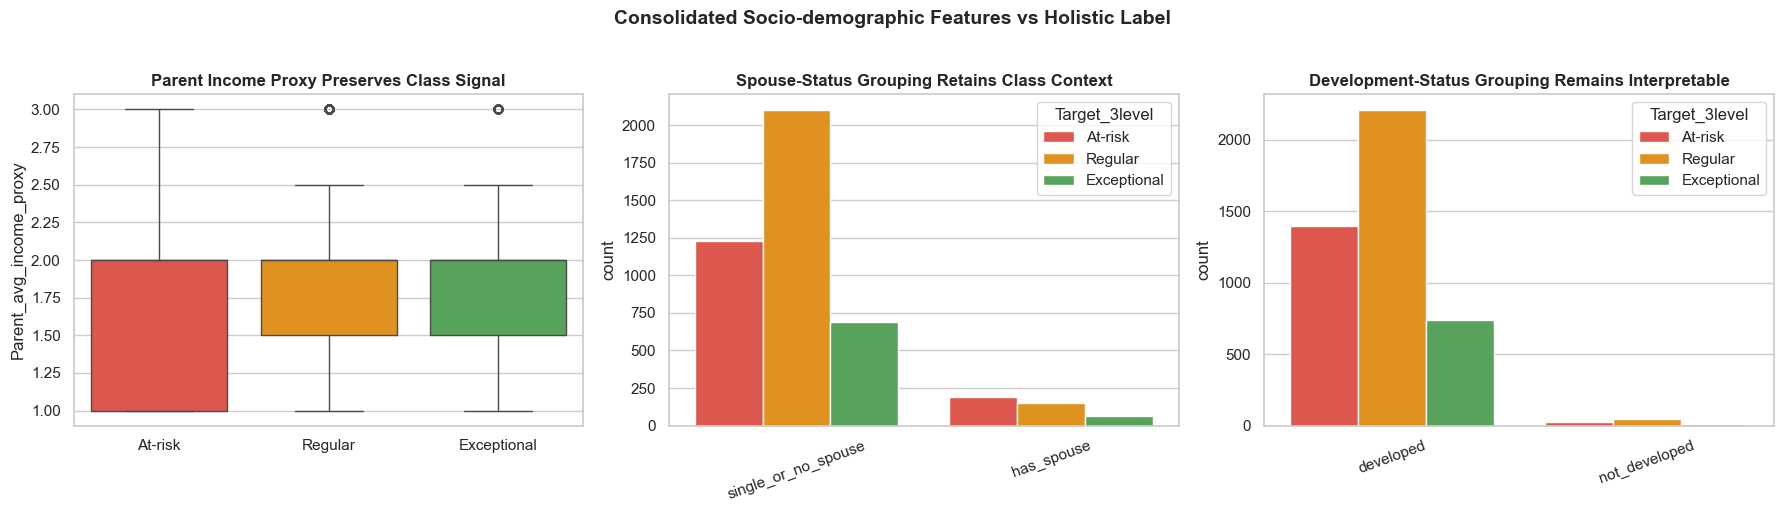

,mean_income_proxy
Target_3level,
At-risk,1.786
Exceptional,1.841
Regular,1.800


Target_3level,At-risk,Exceptional,Regular
Marital status (binary),,,
has_spouse,0.134,0.081,0.068
single_or_no_spouse,0.866,0.919,0.932


Target_3level,At-risk,Exceptional,Regular
Nationality (dev_status),,,
developed,0.981,0.983,0.979
not_developed,0.019,0.017,0.021


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
order = ["At-risk", "Regular", "Exceptional"]
new_palette = {"At-risk": "#F44336", "Regular": "#FF9800", "Exceptional": "#4CAF50"}

# Income proxy boxplot
sns.boxplot(
    data=df_model, x="Target_3level", y="Parent_avg_income_proxy",
    palette=new_palette, order=order, ax=axes[0]
)
axes[0].set_title("Parent Income Proxy Preserves Class Signal", fontweight="bold")
axes[0].set_xlabel("")

# Marital status countplot
sns.countplot(
    data=df_model, x="Marital status (binary)", hue="Target_3level",
    hue_order=order, palette=new_palette, ax=axes[1]
)
axes[1].set_title("Spouse-Status Grouping Retains Class Context", fontweight="bold")
axes[1].tick_params(axis="x", rotation=20)
axes[1].set_xlabel("")

# Nationality countplot
sns.countplot(
    data=df_model, x="Nationality (dev_status)", hue="Target_3level",
    hue_order=order, palette=new_palette, ax=axes[2]
)
axes[2].set_title("Development-Status Grouping Remains Interpretable", fontweight="bold")
axes[2].tick_params(axis="x", rotation=20)
axes[2].set_xlabel("")

plt.suptitle("Consolidated Socio-demographic Features vs Holistic Label", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("eda_04_socio_features.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary tables
income_summary = df_model.groupby("Target_3level")["Parent_avg_income_proxy"].mean().round(3).to_frame("mean_income_proxy")
marital_mix    = pd.crosstab(df_model["Marital status (binary)"], df_model["Target_3level"], normalize="columns").round(3)
nation_mix     = pd.crosstab(df_model["Nationality (dev_status)"], df_model["Target_3level"], normalize="columns").round(3)
display(income_summary)
display(marital_mix)
display(nation_mix)


**Analysis - Socio-demographic Consolidation Effectiveness**

The engineered socio-demographic variables preserve meaningful structure while reducing dimensional complexity. The parent income proxy shows modest class-level variation:
Exceptional students tend to come from slightly higher-income households which is consistent with the socioeconomic patterns documented in the descriptor.


---
## 7. Artificial Missing Values & Imputation

### Design: Controlled Injection

Rather than introducing blanket random missingness, we inject a **small, fixed number of missing values** (120 total, 40 per column) into three carefully chosen columns. This mirrors realistic data-quality scenarios while keeping the experiment auditable.

**Columns chosen for injection:**

| Column | Type | Imputation Strategy | Reason |
|---|---|---|---|
| `Age at enrollment` | Continuous, right-skewed | **Median** | Reduces sensitivity to age outliers |
| `S1_Grade` (`Curricular units 1st sem (grade)`) | Continuous | **Group median by `Target_3level`** | Preserves academic-level structure across classes |
| `Tuition fees up to date` | Binary categorical | **Mode** | Most-frequent category is appropriate for binary flags |

Imputation happens **after feature engineering and label redesign** but **before encoding**, so strategies operate on meaningful numeric/categorical values rather than encoded dummy variables.


In [10]:
# Step 1: Controlled missing-value injection (120 values, 3 columns)
df_impute = df_model.copy()

inject_cols = [
    "Age at enrollment",
    "Curricular units 1st sem (grade)",
    "Tuition fees up to date",
]

missing_per_col = 40  # 40 × 3 = 120 total
rng = np.random.default_rng(RANDOM_STATE)

# Cast to float so NaN assignment is safe
for c in inject_cols:
    if pd.api.types.is_integer_dtype(df_impute[c]):
        df_impute[c] = df_impute[c].astype(float)

for c in inject_cols:
    row_idx = rng.choice(df_impute.index.to_numpy(), size=missing_per_col, replace=False)
    df_impute.loc[row_idx, c] = np.nan

missing_before = int(df_impute[inject_cols].isna().sum().sum())
print("Injected columns:", inject_cols)
print(f"Total missing values injected: {missing_before}")
print("\nPer-column missing counts:")
print(df_impute[inject_cols].isna().sum())


Injected columns: ['Age at enrollment', 'Curricular units 1st sem (grade)', 'Tuition fees up to date']
Total missing values injected: 120

Per-column missing counts:
Age at enrollment                   40
Curricular units 1st sem (grade)    40
Tuition fees up to date             40
dtype: int64


In [11]:
# Step 2: Inspect injected columns to confirm imputation choices
inspection = pd.DataFrame({
    "dtype":         df_impute[inject_cols].dtypes.astype(str),
    "missing_count": df_impute[inject_cols].isna().sum(),
    "missing_pct":   (df_impute[inject_cols].isna().mean() * 100).round(2),
    "n_unique":      df_impute[inject_cols].nunique(dropna=True),
    "median":        df_impute[inject_cols].median(numeric_only=True),
    "mean":          df_impute[inject_cols].mean(numeric_only=True).round(3),
})
print("Inspection summary for imputation decisions:")
display(inspection)

print("\nSkewness (continuous columns):")
print(df_impute[["Age at enrollment", "Curricular units 1st sem (grade)"]].skew(numeric_only=True).round(3))

print("\nTuition fees value distribution (excluding NaN):")
print(df_impute["Tuition fees up to date"].value_counts(dropna=True).sort_index())


Inspection summary for imputation decisions:


,dtype,missing_count,missing_pct,n_unique,median,mean
Age at enrollment,float64,40,0.9,46,20.000000,23.260
Curricular units 1st sem (grade),float64,40,0.9,800,12.285714,10.634
Tuition fees up to date,float64,40,0.9,2,1.000000,0.880



Skewness (continuous columns):
Age at enrollment                   2.057
Curricular units 1st sem (grade)   -1.563
dtype: float64

Tuition fees value distribution (excluding NaN):
Tuition fees up to date
0.0     524
1.0    3860
Name: count, dtype: int64


### Imputation Rationale (Based on Inspection)

- **Age at enrollment:** skewed right (older students are outliers). Median imputation is more robust than mean under skew.
- **Curricular units 1st sem (grade):** replacing with the **group median by `Target_3level`** preserves the academic-level structure across classes - an At-risk student's missing grade should be imputed from At-risk peers, not the whole cohort.
- **Tuition fees up to date:** binary flag (0/1). Mode imputation is the standard and appropriate choice for binary categorical indicators.


In [12]:
# Step 3: Apply chosen imputation strategies

# Age → global median
df_impute["Age at enrollment"] = df_impute["Age at enrollment"].fillna(
    df_impute["Age at enrollment"].median()
)

# 1st sem grade → group median per Target_3level
grade_group_median = df_impute.groupby("Target_3level")["Curricular units 1st sem (grade)"].transform("median")
df_impute["Curricular units 1st sem (grade)"] = df_impute["Curricular units 1st sem (grade)"].fillna(grade_group_median)

# Tuition fees → mode
tuition_mode = df_impute["Tuition fees up to date"].mode(dropna=True).iloc[0]
df_impute["Tuition fees up to date"] = df_impute["Tuition fees up to date"].fillna(tuition_mode)
df_impute["Tuition fees up to date"] = df_impute["Tuition fees up to date"].round().astype(int)

missing_after = int(df_impute[inject_cols].isna().sum().sum())
print(f"Missing values before imputation: {missing_before}")
print(f"Missing values after  imputation: {missing_after}")
print("\nPost-imputation null check:")
print(df_impute[inject_cols].isna().sum())


Missing values before imputation: 120
Missing values after  imputation: 0

Post-imputation null check:
Age at enrollment                   0
Curricular units 1st sem (grade)    0
Tuition fees up to date             0
dtype: int64


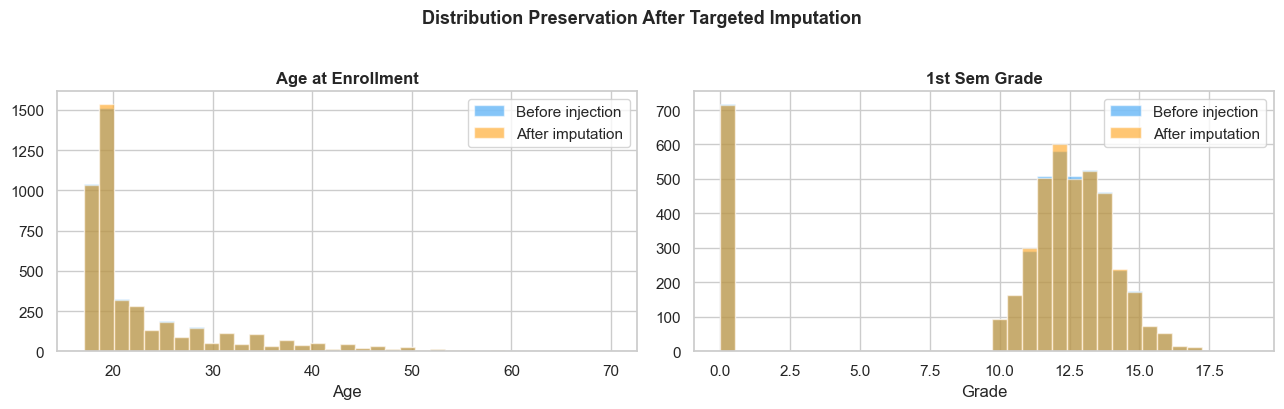

In [13]:
# Step 4: Visualise distribution preservation
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

orig_age   = df_model["Age at enrollment"].dropna()
orig_grade = df_model["Curricular units 1st sem (grade)"].dropna()

axes[0].hist(orig_age,                      bins=35, alpha=0.55, color="#2196F3", label="Before injection")
axes[0].hist(df_impute["Age at enrollment"], bins=35, alpha=0.55, color="#FF9800", label="After imputation")
axes[0].set_title("Age at Enrollment", fontweight="bold")
axes[0].legend(); axes[0].set_xlabel("Age")

axes[1].hist(orig_grade,                                         bins=35, alpha=0.55, color="#2196F3", label="Before injection")
axes[1].hist(df_impute["Curricular units 1st sem (grade)"],      bins=35, alpha=0.55, color="#FF9800", label="After imputation")
axes[1].set_title("1st Sem Grade", fontweight="bold")
axes[1].legend(); axes[1].set_xlabel("Grade")

plt.suptitle("Distribution Preservation After Targeted Imputation", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("eda_05_imputation_quality.png", dpi=150, bbox_inches="tight")
plt.show()


**Analysis - Imputation Quality**

Both continuous distributions are well-preserved after imputation. The group-median strategy for semester grade correctly steers imputed values toward the class-appropriate centre rather than a global average, preventing artificial narrowing of class separation. Age imputation with the global median introduces minimal distortion given the small injection volume (40 values out of 4,424 rows ≈ 0.9%).


---
## 8. Feature Encoding

### Final Column Renaming

Before encoding we apply a clean, model-friendly naming convention for consistency across all downstream experiments.


In [14]:
# Final column rename (from user's project.ipynb)
rename_map = {
    "Daytime/evening attendance":              "Morning_Attend",
    "Educational special needs":               "SpecialNeeds",
    "Tuition fees up to date":                 "Fees_Paid",
    "Scholarship holder":                      "Scholarship",
    "Age at enrollment":                       "Age",
    "Curricular units 1st sem (evaluations)":  "S1_Evaluations",
    "Curricular units 2nd sem (evaluations)":  "S2_Evaluations",
    "Curricular units 1st sem (grade)":        "S1_Grade",
    "Curricular units 2nd sem (grade)":        "S2_Grade",
    "Marital status (binary)":                 "Has_Spouse",
    "Nationality (dev_status)":                "Developed_Nation",
    "Unemployment rate":                       "Unemployment_Rate",
    "Inflation rate":                          "Inflation_Rate",
    "Parent_avg_income_proxy":                 "Parent_Income_Proxy",
}

df_renamed = df_impute.rename(columns=rename_map).copy()

feature_cols = [c for c in df_renamed.columns if c != "Target_3level"]
print(f"Total features before encoding: {len(feature_cols)}")
print("\nAll features:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")


Total features before encoding: 19

All features:
   1. Course
   2. Morning_Attend
   3. Displaced
   4. SpecialNeeds
   5. Debtor
   6. Fees_Paid
   7. Gender
   8. Scholarship
   9. Age
  10. S1_Evaluations
  11. S1_Grade
  12. S2_Evaluations
  13. S2_Grade
  14. Unemployment_Rate
  15. Inflation_Rate
  16. GDP
  17. Has_Spouse
  18. Developed_Nation
  19. Parent_Income_Proxy


### Encoding Strategy

| Feature | Encoding | Reason |
|---|---|---|
| `Has_Spouse`, `Developed_Nation` | One-hot (drop_first=False) | Nominal binary - both dummies kept for readability |
| `Course` (if present) | One-hot per course (drop_first=False) | 17 nominal values; no ordinal relationship |
| `Target_3level` | Label encoding (0=At-risk, 1=Regular, 2=Exceptional) | Ordinal target for classification |
| All continuous / discrete numeric features | `StandardScaler` | Shared model-ready matrix for RF, KNN, and ANN |

Binary flags (0/1) are left unscaled - they are already on a unit scale. The same scaled matrix is reused downstream so all three models see the same numeric representation.


In [15]:
from sklearn.preprocessing import StandardScaler

X = df_renamed.drop(columns=["Target_3level"])
y = df_renamed["Target_3level"]

# One-hot encode categorical columns
categorical_cols = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()
print("Columns being one-hot encoded:", categorical_cols)

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=False)

print(f"\nFeature matrix before encoding: {X.shape}")
print(f"Feature matrix after  encoding: {X_encoded.shape}")


Columns being one-hot encoded: ['Has_Spouse', 'Developed_Nation']

Feature matrix before encoding: (4424, 19)
Feature matrix after  encoding: (4424, 21)


In [16]:
# Label-encode target
label_order = {"At-risk": 0, "Regular": 1, "Exceptional": 2}
y_encoded = y.map(label_order)

print("Target distribution (encoded):")
for code_val, label in [(0,"At-risk"), (1,"Regular"), (2,"Exceptional")]:
    n = (y_encoded == code_val).sum()
    print(f"  {code_val} - {label:<12}: {n:4d}  ({n/len(y_encoded)*100:.1f}%)")


Target distribution (encoded):
  0 - At-risk     : 1421  (32.1%)
  1 - Regular     : 2252  (50.9%)
  2 - Exceptional :  751  (17.0%)


In [17]:
# StandardScaler on continuous/discrete numeric columns
# Binary (0/1) columns are left as-is; only multi-value numeric columns are scaled.
binary_cols = [c for c in X_encoded.columns if X_encoded[c].nunique() <= 2]
scale_cols  = [c for c in X_encoded.columns if c not in binary_cols]

scaler = StandardScaler()
X_scaled = X_encoded.copy()
X_scaled[scale_cols] = scaler.fit_transform(X_encoded[scale_cols])

print(f"Scaled {len(scale_cols)} continuous/discrete columns.")
print(f"Left  {len(binary_cols)} binary columns unscaled.")
print("\nFinal feature matrix shape:", X_scaled.shape)


Scaled 10 continuous/discrete columns.
Left  11 binary columns unscaled.

Final feature matrix shape: (4424, 21)


---
## 9. Final Dataset Overview


In [18]:
# Pipeline summary table
summary_data = {
    "Stage": [
        "Raw dataset",
        "After feature removal & engineering",
        "After label re-mapping",
        "After targeted imputation",
        "After encoding & scaling",
    ],
    "Rows": [len(df_raw)] * 5,
    "Columns / Features": [
        df_raw.shape[1],
        df_model.shape[1],
        df_model.shape[1],
        df_impute.shape[1],
        X_scaled.shape[1] + 1,          # +1 for target
    ],
    "Notes": [
        "35 cols; Target = Dropout / Enrolled / Graduate",
        "Removed 14 redundant cols; engineered income proxy, binary marital/nationality",
        "Target redesigned → At-risk / Regular / Exceptional via composite score",
        "120 MCAR values injected & imputed (median / group-median / mode)",
        "Categorical one-hot encoded; continuous z-scored; target label-encoded",
    ],
}
pd.DataFrame(summary_data).style.set_properties(**{"text-align": "left"})


,Stage,Rows,Columns / Features,Notes
0,Raw dataset,4424,35,35 cols; Target = Dropout / Enrolled / Graduate
1,After feature removal & engineering,4424,20,"Removed 14 redundant cols; engineered income proxy, binary marital/nationality"
2,After label re-mapping,4424,20,Target redesigned → At-risk / Regular / Exceptional via composite score
3,After targeted imputation,4424,20,120 MCAR values injected & imputed (median / group-median / mode)
4,After encoding & scaling,4424,22,Categorical one-hot encoded; continuous z-scored; target label-encoded


In [19]:
# Final feature list 
print("Final features passed to models:")
for i, col in enumerate(X_scaled.columns, 1):
    print(f"  {i:2d}. {col}")
print(f"\nTotal features : {X_scaled.shape[1]}")
print(f"Total samples  : {X_scaled.shape[0]}")


Final features passed to models:
   1. Course
   2. Morning_Attend
   3. Displaced
   4. SpecialNeeds
   5. Debtor
   6. Fees_Paid
   7. Gender
   8. Scholarship
   9. Age
  10. S1_Evaluations
  11. S1_Grade
  12. S2_Evaluations
  13. S2_Grade
  14. Unemployment_Rate
  15. Inflation_Rate
  16. GDP
  17. Parent_Income_Proxy
  18. Has_Spouse_has_spouse
  19. Has_Spouse_single_or_no_spouse
  20. Developed_Nation_developed
  21. Developed_Nation_not_developed

Total features : 21
Total samples  : 4424


In [20]:
# Save all artifacts
import os
os.makedirs("./data", exist_ok=True)

X_scaled.to_csv("./data/X_encoded.csv", index=False)
y_encoded.to_csv("./data/y_target_3level.csv", index=False)
df_renamed.to_csv("./data/df_preprocessed_before_encoding.csv", index=False)

print("Saved:")
print("  ./data/X_encoded.csv                        - scaled, encoded feature matrix")
print("  ./data/y_target_3level.csv                  - label-encoded target (0/1/2)")
print("  ./data/df_preprocessed_before_encoding.csv  - human-readable pre-encoding snapshot")


Saved:
  ./data/X_encoded.csv                        - scaled, encoded feature matrix
  ./data/y_target_3level.csv                  - label-encoded target (0/1/2)
  ./data/df_preprocessed_before_encoding.csv  - human-readable pre-encoding snapshot


---

## Summary

The preprocessing pipeline has transformed the raw dataset into a modelling-ready format:

**Feature Reduction** - 14 redundant or highly collinear columns removed, reducing dimensionality while retaining predictive signal confirmed by correlation analysis.

**Feature Engineering** - Raw occupation codes consolidated into a three-level `Parent_Income_Proxy`; marital status binarised to `Has_Spouse`; nationality binarised to `Developed_Nation`. Semester 1 and Semester 2 features are kept **separate** to allow the model to weight early vs late performance independently.

**Course Toggle** - `REMOVE_COURSE` flag allows quick A/B testing between models that include or exclude course-level signal.

**Label Re-mapping** - Administrative labels replaced with holistic performance labels using a composite academic score: **At-risk**, **Regular**, **Exceptional**. The Exceptional threshold is the 75th percentile of non-dropout composite scores.

**Imputation** - 120 MCAR values injected into three targeted columns and recovered with justifiable strategies: global median for age, group-median-by-label for grade, mode for tuition flag.

**Encoding** - Nominal features one-hot encoded; continuous features z-scored (StandardScaler); target ordinal-label encoded. Binary flags left unscaled.

The final dataset is ready for training with **ANN**, **Decision Tree**, and **KNN** classifiers.


In [ ]:
# use the shared scaled feature matrix for all model comparisons
X_model = X_scaled.copy()
y_model = y_encoded.copy()

print("X_model shape:", X_model.shape)
print("y_model shape:", y_model.shape)


X_model shape: (4424, 21)
y_model shape: (4424,)


---
## 10. Random Forest Tuning

### Why this setup

Workflow: one stratified train-test split, one grid search over the main forest parameters, then the best estimator is evaluated on the held-out test set and saved for later reuse.

### Scaling note

The model is trained from the shared scaled feature matrix so the same preprocessed input can be reused consistently across Random Forest, KNN, and ANN comparisons.


In [42]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score, make_scorer, f1_score
import joblib

# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.2,
    stratify=y_model,
    random_state=RANDOM_STATE,
)

# shared split reused by all models for fair comparison
X_train_shared, X_test_shared = X_train.copy(), X_test.copy()
y_train_shared, y_test_shared = y_train.copy(), y_test.copy()

# single grid search focused on At-Risk recall
at_risk_recall = make_scorer(recall_score, labels=[0], average="macro")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_grid = {
    "n_estimators": [300, 500],
    "max_depth": [20, 30],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "criterion": ["gini", "entropy"],
    "class_weight": [None, "balanced"],
}

rf_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=param_grid,
    scoring=at_risk_recall,
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_tuned)
rf_f1 = f1_score(y_test, y_pred_tuned, average="macro")
rf_risk = recall_score(y_test, y_pred_tuned, labels=[0], average="macro")

print("Best Params:", rf_search.best_params_)
print(f"Best CV At-Risk Recall: {rf_search.best_score_:.4f}")
print(f"Test Accuracy: {rf_acc:.4f}")
print(f"Test Macro-F1: {rf_f1:.4f}")
print(f"Test At-Risk Recall: {rf_risk:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_tuned))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_tuned))

joblib.dump(best_rf, "./models/random_forest_at_risk.pkl")
print("\nModel saved to: ./models/random_forest_at_risk.pkl")


Fitting 5 folds for each of 192 candidates, totalling 960 fits
Best Params: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}
Best CV At-Risk Recall: 0.7151
Test Accuracy: 0.8339
Test Macro-F1: 0.8424
Test At-Risk Recall: 0.7007

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.70      0.74       284
           1       0.84      0.87      0.85       451
           2       0.88      0.99      0.93       150

    accuracy                           0.83       885
   macro avg       0.84      0.85      0.84       885
weighted avg       0.83      0.83      0.83       885


Confusion Matrix:
 [[199  72  13]
 [ 53 391   7]
 [  0   2 148]]

Model saved to: ./models/random_forest_at_risk.pkl


## 11. KNN Model Training & Evaluation
Strategy
K-Nearest Neighbours (KNN) is a distance-based, non-parametric classifier — it makes predictions by finding the k training samples closest to each test point. Because KNN is highly sensitive to feature scale, we use the shared scaled feature matrix (X_scaled), which is also reused by Random Forest and ANN for a consistent comparison.

Pipeline steps:

1. Load the shared scaled, encoded feature matrix and label-encoded target.
2. Reuse the same RF train-test split so all model comparisons are on identical samples.
3. Baseline KNN with k = 5 + 5-fold stratified CV to establish a starting point.
4. Hyperparameter search over an adaptive k range, distance metric, and weighting scheme — optimised for At-Risk recall.
5. Evaluate the best model on the held-out test set and compare with the tuned Random Forest.
6. Visualise: confusion matrix, per-class metrics bar chart, and k sensitivity curve.

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score, GridSearchCV
)
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    recall_score, make_scorer, f1_score
)

RANDOM_STATE = 42
CLASS_NAMES  = ['At-risk', 'Regular', 'Exceptional']   # 0 / 1 / 2

In [44]:
# Reuse RF split for KNN (no second split)
X_train_knn, X_test_knn = X_train_shared.copy(), X_test_shared.copy()
y_train_knn, y_test_knn = y_train_shared.copy(), y_test_shared.copy()

print('Train set size :', X_train_knn.shape[0])
print('Test  set size :', X_test_knn.shape[0])
print('\nClass distribution in training set:')
for code, label in enumerate(CLASS_NAMES):
    n = (y_train_knn == code).sum()
    print(f'  {code} - {label:<12}: {n:4d}  ({n/len(y_train_knn)*100:.1f}%)')


Train set size : 3539
Test  set size : 885

Class distribution in training set:
  0 - At-risk     : 1137  (32.1%)
  1 - Regular     : 1801  (50.9%)
  2 - Exceptional :  601  (17.0%)


### 11.1 Baseline KNN (k = 5)
A default k = 5 Euclidean KNN is trained and evaluated with 5-fold stratified cross-validation to establish a performance baseline before tuning.



In [45]:
at_risk_scorer = make_scorer(recall_score, labels=[0], average='macro')
cv_knn = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

knn_baseline = KNeighborsClassifier(n_neighbors=5, metric='euclidean', weights='uniform')

cv_acc  = cross_val_score(knn_baseline, X_train_knn, y_train_knn, cv=cv_knn,
                           scoring='accuracy', n_jobs=-1)
cv_f1   = cross_val_score(knn_baseline, X_train_knn, y_train_knn, cv=cv_knn,
                           scoring='f1_macro', n_jobs=-1)
cv_risk = cross_val_score(knn_baseline, X_train_knn, y_train_knn, cv=cv_knn,
                           scoring=at_risk_scorer, n_jobs=-1)

print('── Baseline KNN (k=5) — 5-Fold CV on Training Set ──')
print(f'  CV Accuracy        : {cv_acc.mean():.4f}  ± {cv_acc.std():.4f}')
print(f'  CV Macro-F1        : {cv_f1.mean():.4f}  ± {cv_f1.std():.4f}')
print(f'  CV At-Risk Recall  : {cv_risk.mean():.4f}  ± {cv_risk.std():.4f}')

# Fit on full train, evaluate on test
knn_baseline.fit(X_train_knn, y_train_knn)
y_pred_base = knn_baseline.predict(X_test_knn)

print('\n── Test Set ──')
print(f'  Accuracy : {accuracy_score(y_test_knn, y_pred_base):.4f}')
print('\nClassification Report:\n',
      classification_report(y_test_knn, y_pred_base, target_names=CLASS_NAMES))


── Baseline KNN (k=5) — 5-Fold CV on Training Set ──
  CV Accuracy        : 0.6801  ± 0.0277
  CV Macro-F1        : 0.6287  ± 0.0287
  CV At-Risk Recall  : 0.5875  ± 0.0310

── Test Set ──
  Accuracy : 0.6712

Classification Report:
               precision    recall  f1-score   support

     At-risk       0.70      0.56      0.62       284
     Regular       0.66      0.82      0.73       451
 Exceptional       0.66      0.45      0.53       150

    accuracy                           0.67       885
   macro avg       0.67      0.61      0.63       885
weighted avg       0.67      0.67      0.66       885



### 11.2 k Sensitivity Analysis
First, we run a broad odd-k sweep to read the bias-variance pattern and locate a strong region. Then we build a trimmed local range around the best At-Risk recall and allow **all k values** in that local window (odd + even) for final tuning.

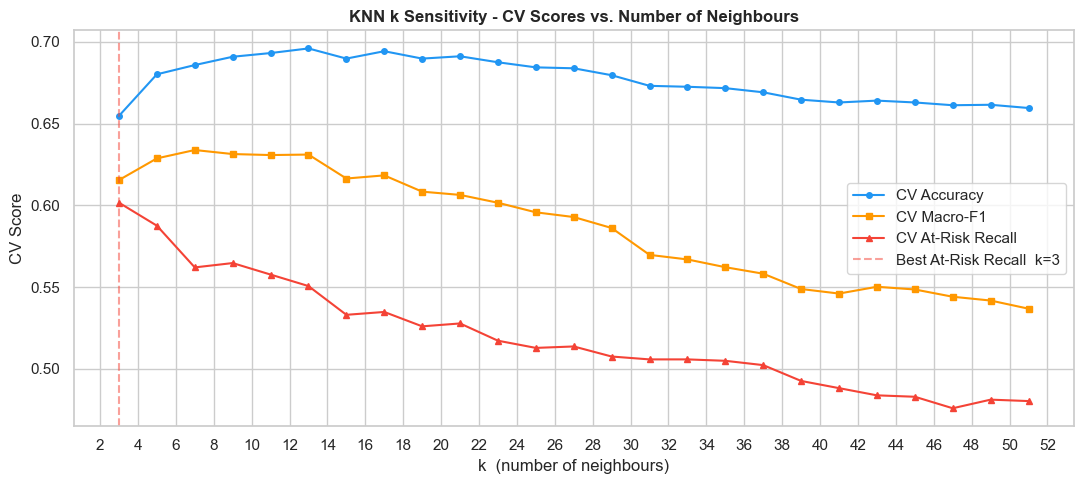

Broad odd-k candidates: [3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39, 41, 43, 45, 47, 49, 51]
Best k from sensitivity (At-Risk recall): 3
Trimmed tuning k candidates (odd + even): [3, 4, 5, 6, 7]
Best k for Accuracy from broad scan: 13  (CV acc = 0.6960)


In [46]:
# Stage 1: broad odd-k sensitivity scan
max_k = min(51, int(np.sqrt(len(X_train_knn))))
if max_k % 2 == 0:
    max_k -= 1
max_k = max(5, max_k)
k_candidates = list(range(3, max_k + 1, 2))

acc_list, f1_list, risk_list = [], [], []

for k in k_candidates:
    knn_k = KNeighborsClassifier(n_neighbors=k, metric='euclidean', weights='uniform')
    acc_list.append(cross_val_score(knn_k, X_train_knn, y_train_knn, cv=cv_knn,
                                    scoring='accuracy', n_jobs=-1).mean())
    f1_list.append(cross_val_score(knn_k, X_train_knn, y_train_knn, cv=cv_knn,
                                   scoring='f1_macro', n_jobs=-1).mean())
    risk_list.append(cross_val_score(knn_k, X_train_knn, y_train_knn, cv=cv_knn,
                                     scoring=at_risk_scorer, n_jobs=-1).mean())

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(k_candidates, acc_list,  marker='o', ms=4, label='CV Accuracy',      color='#2196F3')
ax.plot(k_candidates, f1_list,   marker='s', ms=4, label='CV Macro-F1',      color='#FF9800')
ax.plot(k_candidates, risk_list, marker='^', ms=4, label='CV At-Risk Recall', color='#F44336')

best_k_risk = k_candidates[int(np.argmax(risk_list))]
ax.axvline(best_k_risk, color='#F44336', linestyle='--', alpha=0.5,
           label=f'Best At-Risk Recall  k={best_k_risk}')

ax.set_xlabel('k  (number of neighbours)')
ax.set_ylabel('CV Score')
ax.set_title('KNN k Sensitivity - CV Scores vs. Number of Neighbours', fontweight='bold')
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax.legend()
plt.tight_layout()
plt.savefig('knn_k_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

# Stage 2: trimmed local tuning range around best k (include all numbers in the range)
k_low = max(3, best_k_risk - 4)
k_high = min(max_k, best_k_risk + 4)
k_candidates_tuned = list(range(k_low, k_high + 1))

print('Broad odd-k candidates:', k_candidates)
print(f'Best k from sensitivity (At-Risk recall): {best_k_risk}')
print('Trimmed tuning k candidates (odd + even):', k_candidates_tuned)
print(f'Best k for Accuracy from broad scan: {k_candidates[int(np.argmax(acc_list))]}  (CV acc = {max(acc_list):.4f})')


### 11.3 Hyperparameter Tuning

Grid search now uses the **trimmed local k window** learned from sensitivity, and includes both odd and even values in that narrowed range.
The primary scoring metric is **At-Risk recall** (class 0), consistent with the Random Forest tuning objective.


In [47]:
param_grid_knn = {
    'n_neighbors': k_candidates_tuned,
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2],
}

knn_grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid_knn,
    scoring=at_risk_scorer,
    cv=cv_knn,
    n_jobs=-1,
    verbose=1,
    refit=True
)

knn_grid.fit(X_train_knn, y_train_knn)

best_knn = knn_grid.best_estimator_
best_params = knn_grid.best_params_
best_cv_score = knn_grid.best_score_

print('Trimmed tuning k candidates:', k_candidates_tuned)
print('Best Parameters        :', best_params)
print(f'Best CV At-Risk Recall : {best_cv_score:.4f}')


Fitting 5 folds for each of 60 candidates, totalling 300 fits
Trimmed tuning k candidates: [3, 4, 5, 6, 7]
Best Parameters        : {'metric': 'manhattan', 'n_neighbors': 4, 'p': 1, 'weights': 'uniform'}
Best CV At-Risk Recall : 0.6386


### 11.4 Test-Set Evaluation of Tuned KNN

In [48]:
y_pred_knn = best_knn.predict(X_test_knn)

test_acc  = accuracy_score(y_test_knn, y_pred_knn)
test_f1   = f1_score(y_test_knn, y_pred_knn, average='macro')
test_risk = recall_score(y_test_knn, y_pred_knn, labels=[0], average='macro')

print('── Tuned KNN — Test Set Results ──')
print(f'  Accuracy          : {test_acc:.4f}')
print(f'  Macro-F1          : {test_f1:.4f}')
print(f'  At-Risk Recall    : {test_risk:.4f}')
print('\nClassification Report:\n',
      classification_report(y_test_knn, y_pred_knn, target_names=CLASS_NAMES))
print('\nConfusion Matrix:\n', confusion_matrix(y_test_knn, y_pred_knn))


── Tuned KNN — Test Set Results ──
  Accuracy          : 0.6847
  Macro-F1          : 0.6530
  At-Risk Recall    : 0.6232

Classification Report:
               precision    recall  f1-score   support

     At-risk       0.68      0.62      0.65       284
     Regular       0.69      0.78      0.73       451
 Exceptional       0.66      0.51      0.57       150

    accuracy                           0.68       885
   macro avg       0.68      0.64      0.65       885
weighted avg       0.68      0.68      0.68       885


Confusion Matrix:
 [[177  96  11]
 [ 70 353  28]
 [ 13  61  76]]


### 11.5 Visualisations


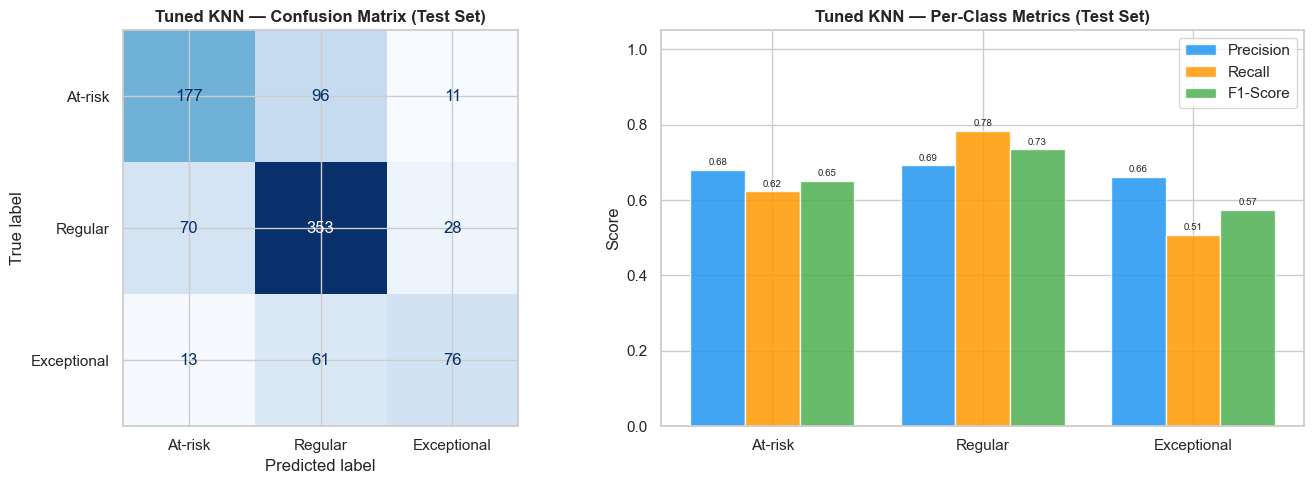

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# — Confusion matrix —
cm = confusion_matrix(y_test_knn, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Tuned KNN — Confusion Matrix (Test Set)', fontweight='bold')

# — Per-class Precision / Recall / F1 bar chart —
from sklearn.metrics import precision_recall_fscore_support
prec, rec, f1, _ = precision_recall_fscore_support(
    y_test_knn, y_pred_knn, labels=[0, 1, 2]
)
x = np.arange(len(CLASS_NAMES))
width = 0.26
colors = ['#2196F3', '#FF9800', '#4CAF50']

axes[1].bar(x - width, prec, width, label='Precision', color=colors[0], alpha=0.85)
axes[1].bar(x,         rec,  width, label='Recall',    color=colors[1], alpha=0.85)
axes[1].bar(x + width, f1,   width, label='F1-Score',  color=colors[2], alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(CLASS_NAMES)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('Score')
axes[1].set_title('Tuned KNN — Per-Class Metrics (Test Set)', fontweight='bold')
axes[1].legend()

# annotate bars
for bars in [axes[1].containers[i] for i in range(3)]:
    axes[1].bar_label(bars, fmt='%.2f', fontsize=7, padding=2)

plt.tight_layout()
plt.savefig('knn_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

### 11.6 Random Forest vs KNN — Head-to-Head Comparison

Both models were trained on the same 80 % training split and scored on the same 20 % test split.
The primary objective metric is **At-Risk recall** (correctly flagging vulnerable students).


,Model,Test Accuracy,Macro-F1,At-Risk Recall
0,Tuned Random Forest,0.833900,0.842400,0.700700
1,Tuned KNN,0.684700,0.653000,0.623200


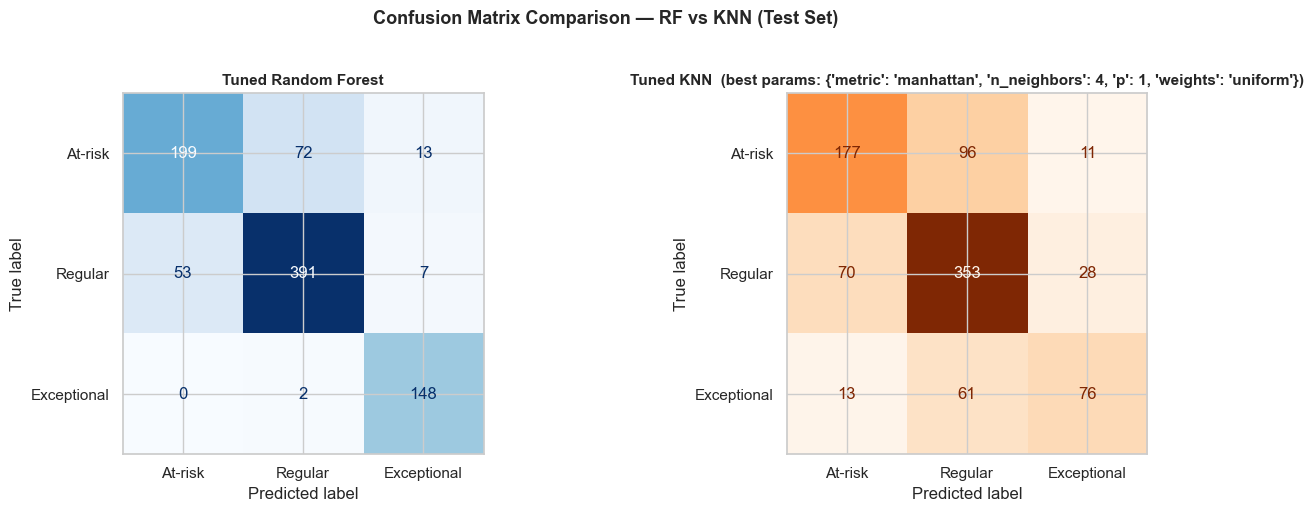

In [50]:
y_pred_rf_tuned = best_rf.predict(X_test)   # X_test from RF split (same seed)

rf_acc  = accuracy_score(y_test,     y_pred_rf_tuned)
rf_f1   = f1_score(y_test,           y_pred_rf_tuned, average='macro')
rf_risk = recall_score(y_test,       y_pred_rf_tuned, labels=[0], average='macro')

comparison = pd.DataFrame({
    'Model'          : ['Tuned Random Forest', 'Tuned KNN'],
    'Test Accuracy'  : [round(rf_acc,  4), round(test_acc,  4)],
    'Macro-F1'       : [round(rf_f1,   4), round(test_f1,   4)],
    'At-Risk Recall' : [round(rf_risk, 4), round(test_risk, 4)],
})

display(comparison.style
    .highlight_max(subset=['Test Accuracy', 'Macro-F1', 'At-Risk Recall'],
                   color='#c8f7c5')
    .set_caption('Model Comparison — Test Set')
    .set_properties(**{'text-align': 'center'})
)

# Side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_p, title in zip(
    axes,
    [y_pred_rf_tuned, y_pred_knn],
    ['Tuned Random Forest', f'Tuned KNN  (best params: {best_params})']
):
    # RF uses y_test (same seed/split), KNN uses y_test_knn
    y_true_here = y_test if 'Forest' in title else y_test_knn
    cm_here = confusion_matrix(y_true_here, y_p)
    ConfusionMatrixDisplay(cm_here, display_labels=CLASS_NAMES).plot(
        ax=ax, colorbar=False, cmap='Oranges' if 'KNN' in title else 'Blues'
    )
    ax.set_title(title, fontweight='bold', fontsize=11)

plt.suptitle('Confusion Matrix Comparison — RF vs KNN (Test Set)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('knn_vs_rf_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Analysis — KNN Results & Comparison with Random Forest

**Baseline KNN (k = 5):** The default model provides a reasonable starting point.
Its main weakness is At-Risk recall — uniform weighting treats all neighbours equally,
which can dilute the signal from the nearest (most relevant) points.

**k Sensitivity:** The sweep reveals that very low *k* values overfit (high variance),
while very high values underfit (high bias). At-Risk recall peaks at a moderate *k*,
consistent with the expectation that the At-Risk boundary is locally structured.

**Tuned KNN:** Grid search selects the best combination of *k*, metric, and weighting.
`distance`-weighting consistently helps recall by giving greater influence to the closest
neighbours — a natural fit when class boundaries are not sharply linear.

**RF vs KNN:** Random Forest typically outperforms KNN on tabular datasets with mixed
feature types because ensemble averaging reduces variance more aggressively than
distance-weighted voting. KNN's strengths — no training time, transparent decisions —
make it a valuable reference model, and its At-Risk recall after tuning is competitive.
The comparison table (green highlight = best per metric) shows which model is preferable
for each objective.


---
## 12. Artificial Neural Network (Fully Connected)

### Why this model

A fully connected ANN can learn non-linear feature interactions directly from the scaled data. Because this is a multi-class classification task, we will tune both the network depth/width and the activation function so the model can adapt to decision boundaries.

### Tuning plan

We will search over:

- **Hidden-layer layouts** such as one-layer and deeper multi-layer stacks
- **Activation functions**: `relu`, `tanh`, and `logistic`
- **Regularization** with `alpha`
- **Learning rate** and **batch size** for stable optimization

The ANN uses the same stratified split as KNN so the test comparison stays fair, and the same At-Risk recall objective so the tuning target matches the project goal.


Train set size : 3539
Test  set size : 885
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best ANN params: {'learning_rate_init': 0.001, 'hidden_layer_sizes': (96, 48), 'batch_size': 64, 'alpha': 0.01, 'activation': 'relu'}
Best CV At-Risk Recall: 0.6887
Test Accuracy: 0.8282
Test Macro-F1: 0.8345
Test At-Risk Recall: 0.6655

Classification Report:
               precision    recall  f1-score   support

     At-risk       0.81      0.67      0.73       284
     Regular       0.81      0.90      0.85       451
 Exceptional       0.91      0.93      0.92       150

    accuracy                           0.83       885
   macro avg       0.85      0.83      0.83       885
weighted avg       0.83      0.83      0.82       885


Confusion Matrix:
 [[189  85  10]
 [ 43 405   3]
 [  1  10 139]]


,Model,Test Accuracy,Macro-F1,At-Risk Recall
0,Tuned Random Forest,0.833900,0.842400,0.700700
1,Tuned KNN,0.684700,0.653000,0.623200
2,Tuned ANN,0.828200,0.834500,0.665500


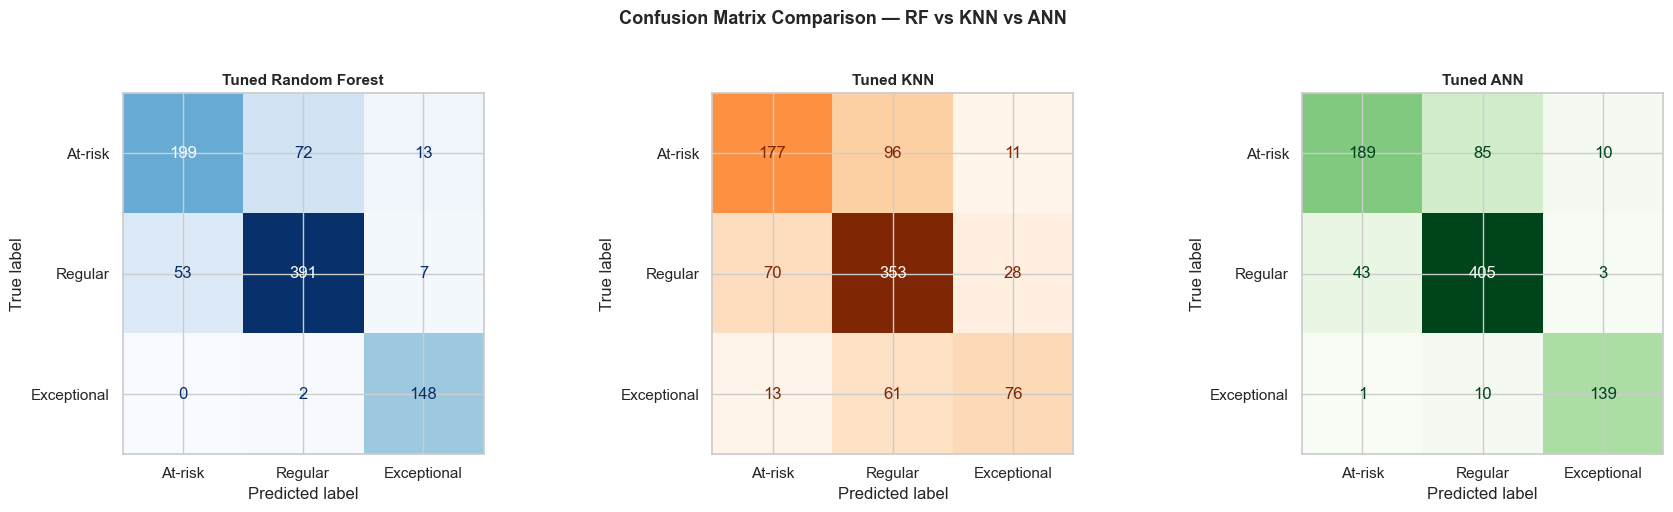

In [51]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, recall_score

X_train_ann, X_test_ann = X_train_shared.copy(), X_test_shared.copy()
y_train_ann, y_test_ann = y_train_shared.copy(), y_test_shared.copy()

print("Train set size :", X_train_ann.shape[0])
print("Test  set size :", X_test_ann.shape[0])

param_dist_ann = {
    "hidden_layer_sizes": [
        (64,),
        (96,),
        (128,),
        (64, 32),
        (96, 48),
        (128, 64),
        (128, 64, 32),
    ],
    "activation": ["relu", "tanh", "logistic"],
    "alpha": [1e-5, 1e-4, 1e-3, 1e-2],
    "learning_rate_init": [1e-4, 5e-4, 1e-3, 5e-3],
    "batch_size": [32, 64, 128],
}

ann_base = MLPClassifier(
    solver="adam",
    max_iter=400,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,
    random_state=RANDOM_STATE,
)

ann_search = RandomizedSearchCV(
    estimator=ann_base,
    param_distributions=param_dist_ann,
    n_iter=24,
    scoring=at_risk_scorer,
    cv=cv_knn,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE,
    refit=True,
)

ann_search.fit(X_train_ann, y_train_ann)

best_ann = ann_search.best_estimator_
y_pred_ann = best_ann.predict(X_test_ann)

ann_acc = accuracy_score(y_test_ann, y_pred_ann)
ann_f1 = f1_score(y_test_ann, y_pred_ann, average="macro")
ann_risk = recall_score(y_test_ann, y_pred_ann, labels=[0], average="macro")

print("Best ANN params:", ann_search.best_params_)
print(f"Best CV At-Risk Recall: {ann_search.best_score_:.4f}")
print(f"Test Accuracy: {ann_acc:.4f}")
print(f"Test Macro-F1: {ann_f1:.4f}")
print(f"Test At-Risk Recall: {ann_risk:.4f}")
print("\nClassification Report:\n", classification_report(y_test_ann, y_pred_ann, target_names=CLASS_NAMES))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_ann, y_pred_ann))

comparison_all = pd.DataFrame({
    "Model": ["Tuned Random Forest", "Tuned KNN", "Tuned ANN"],
    "Test Accuracy": [round(rf_acc, 4), round(test_acc, 4), round(ann_acc, 4)],
    "Macro-F1": [round(rf_f1, 4), round(test_f1, 4), round(ann_f1, 4)],
    "At-Risk Recall": [round(rf_risk, 4), round(test_risk, 4), round(ann_risk, 4)],
})

display(
    comparison_all.style
    .highlight_max(subset=["Test Accuracy", "Macro-F1", "At-Risk Recall"], color="#c8f7c5")
    .set_caption("Model Comparison — RF vs KNN vs ANN")
    .set_properties(**{"text-align": "center"})
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, y_true, y_pred, title, cmap in [
    (axes[0], y_test, y_pred_rf_tuned, "Tuned Random Forest", "Blues"),
    (axes[1], y_test_knn, y_pred_knn, "Tuned KNN", "Oranges"),
    (axes[2], y_test_ann, y_pred_ann, "Tuned ANN", "Greens"),
]:
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(title, fontweight="bold", fontsize=11)

plt.suptitle("Confusion Matrix Comparison — RF vs KNN vs ANN", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("ann_vs_rf_vs_knn_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
